# Overall Stargal Stats

Preliminary work for star-gal separation. Performs statistics on lephare outputs carried on two synthetic magnitude libraries (one composed of star SED, another of galaxies SEDs).

SPLIT add two columns to LePHARE:
 - pdz_flag: describes the quality of the computed redshift
 - s-type: the most likely type of star (OBAFGKM) if the observed source was a star


In [1]:
### Libraries ###
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys

In [2]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(base_dir)
from scripts import statsplot as lsp
%matplotlib inline

## Tests on DC2

In [4]:
### Generate pandas df from output catalog ###
CAT_OUT = os.path.join(base_dir, 'simulation_catalogs/DC2/dp02_dc2_62_BT_LSST_full.out')
photoz_dc2 = lsp.lephare_to_pandas(CAT_OUT)
### Clean error values
photoz_dc2 = photoz_dc2[photoz_dc2['Z_BEST'] != -99.9]
print(list(photoz_dc2.columns.values))
photoz_dc2

['IDENT', 'Z_BEST', 'Z_MED', 'Z_MODE', 'CHI_BEST', 'MOD_BEST', 'SCALE_BEST', 'NBAND_USED', 'Z_SEC', 'CHI_SEC', 'MOD_STAR', 'CHI_STAR', 'MAG_OBS0', 'MAG_OBS1', 'MAG_OBS2', 'MAG_OBS3', 'MAG_OBS4', 'MAG_OBS5', 'ERR_MAG_OBS0', 'ERR_MAG_OBS1', 'ERR_MAG_OBS2', 'ERR_MAG_OBS3', 'ERR_MAG_OBS4', 'ERR_MAG_OBS5', 'ZSPEC']


,IDENT,Z_BEST,Z_MED,Z_MODE,CHI_BEST,MOD_BEST,SCALE_BEST,NBAND_USED,Z_SEC,CHI_SEC,...,MAG_OBS3,MAG_OBS4,MAG_OBS5,ERR_MAG_OBS0,ERR_MAG_OBS1,ERR_MAG_OBS2,ERR_MAG_OBS3,ERR_MAG_OBS4,ERR_MAG_OBS5,ZSPEC
0,1651413688361421449,0.60990,0.6933,0.5955,2.52301,82,0.012003,6,1.99,5.506290e+00,...,25.452,25.985,24.877,0.445,0.249,0.155,0.191,0.823,0.523,0.00000
1,1651413688361451863,1.61700,1.3936,0.8543,5.76531,37,1.417940,6,-99.90,1.000000e+09,...,24.611,24.224,24.009,2.443,0.108,0.091,0.082,0.145,0.210,0.00000
2,1651413688361451723,0.07368,1.2715,0.0731,7.65501,99,0.000028,6,1.36,9.656750e+00,...,26.706,26.399,25.543,1.066,0.125,0.343,0.362,0.781,0.741,1.58383
3,1651413688361451008,1.28600,1.3489,1.3964,5.86742,90,0.026395,6,0.05,6.424590e+00,...,27.495,25.900,25.414,1.268,0.159,0.302,0.793,0.519,0.667,1.57419
4,1651413688361450766,0.03779,0.1734,0.0183,1.59516,76,0.000021,6,2.00,4.055760e+00,...,25.918,26.159,26.046,3.301,0.140,0.140,0.254,0.835,1.465,1.40663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267032,1651220174314963390,1.08100,1.1038,1.0575,10.20890,86,0.265720,6,-99.90,1.000000e+09,...,24.035,23.550,23.573,0.135,0.029,0.031,0.040,0.074,0.153,1.61999
267033,1651220174314979605,0.78200,1.1879,1.7542,1.87006,90,0.010327,6,-99.90,1.000000e+09,...,26.260,25.663,27.302,0.425,0.237,0.225,0.257,0.448,4.268,0.99160
267034,1651220174314968068,1.69900,1.6433,1.7462,11.13360,90,0.151761,6,0.41,1.139190e+01,...,25.860,25.663,24.291,0.200,0.083,0.077,0.209,0.531,0.267,1.29311
267035,1567956357766723215,1.39000,1.3509,1.4291,1.75318,84,0.059639,6,0.07,2.169420e+00,...,26.612,25.948,25.386,1.706,0.171,0.274,0.479,0.680,0.886,2.32176


In [5]:
### error observed mag bining
photoz_dc2_errmag0001 = photoz_dc2[photoz_dc2['ERR_MAG_OBS1']<=0.01]
photoz_dc2_errmag001 = photoz_dc2[(photoz_dc2['ERR_MAG_OBS1']>0.01) & (photoz_dc2['ERR_MAG_OBS1']<=0.1)]
photoz_dc2_errmag01 = photoz_dc2[(photoz_dc2['ERR_MAG_OBS1']>0.1)]# & (photoz_dc2['ERR_MAG_OBS1']<=1)]
#photoz_dc2_errmag1 = photoz_dc2[(photoz_dc2['ERR_MAG_OBS1']>1)]

### observed mag bining
photoz_dc2_mag20 = photoz_dc2[photoz_dc2['MAG_OBS1']<=20]
photoz_dc2_mag23 = photoz_dc2[(photoz_dc2['MAG_OBS1']>20) & (photoz_dc2['MAG_OBS1']<=23)]
photoz_dc2_mag26 = photoz_dc2[(photoz_dc2['MAG_OBS1']>23) & (photoz_dc2['MAG_OBS1']<=26)]
photoz_dc2_mag27 = photoz_dc2[(photoz_dc2['MAG_OBS1']>26)]

### only stars
photoz_dc2_stars = photoz_dc2[photoz_dc2['ZSPEC']==0]

### only gal
photoz_dc2_gal = photoz_dc2[photoz_dc2['ZSPEC']>0]

In [6]:
photoz_dc2_magbin = (photoz_dc2_mag27, photoz_dc2_mag26, photoz_dc2_mag23, photoz_dc2_mag20)
photoz_dc2_magbin_labels = ['Gmag > 26', 'Gmag < 26', 'Gmag < 23', 'Gmag < 20']
photoz_dc2_emagbin = (photoz_dc2_errmag01, photoz_dc2_errmag001, photoz_dc2_errmag0001)
photoz_dc2_emagbin_labels = ['Gemag > 0.1', 'Gemag < 0.1', 'Gemag < 0.01']


zz_plot

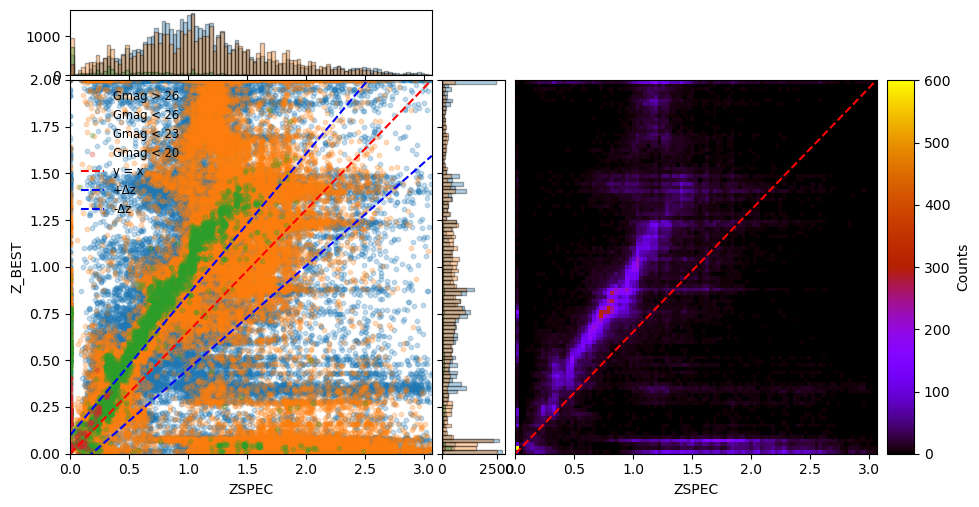

In [7]:
lsp.scatter_vs_hist2D(data=photoz_dc2_magbin, cmaps='gnuplot', deltaz=0.1, labels=photoz_dc2_magbin_labels, xlabel='ZSPEC', ylabel='Z_BEST')
# lsp.scatter_vs_hist2D(data=photoz_dc2_stars, cmaps='gnuplot', deltaz=0.1, xlabel='ZSPEC', ylabel='Z_BEST')

Chi2 distribution, pit and qq-plot

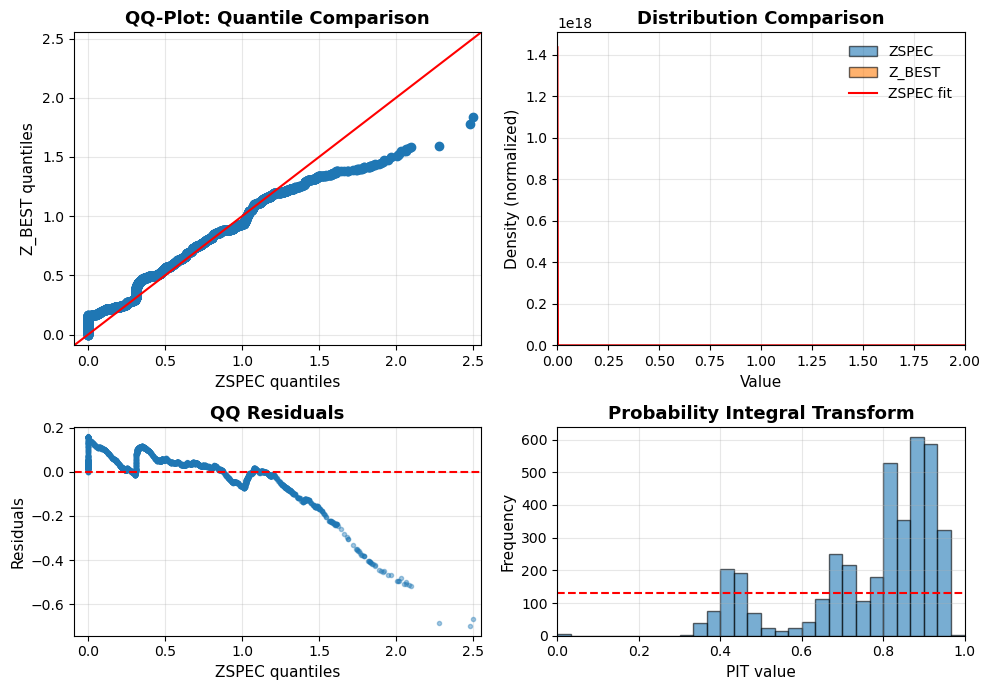

In [8]:
lsp.pit_qqplot(data = photoz_dc2_magbin[2])

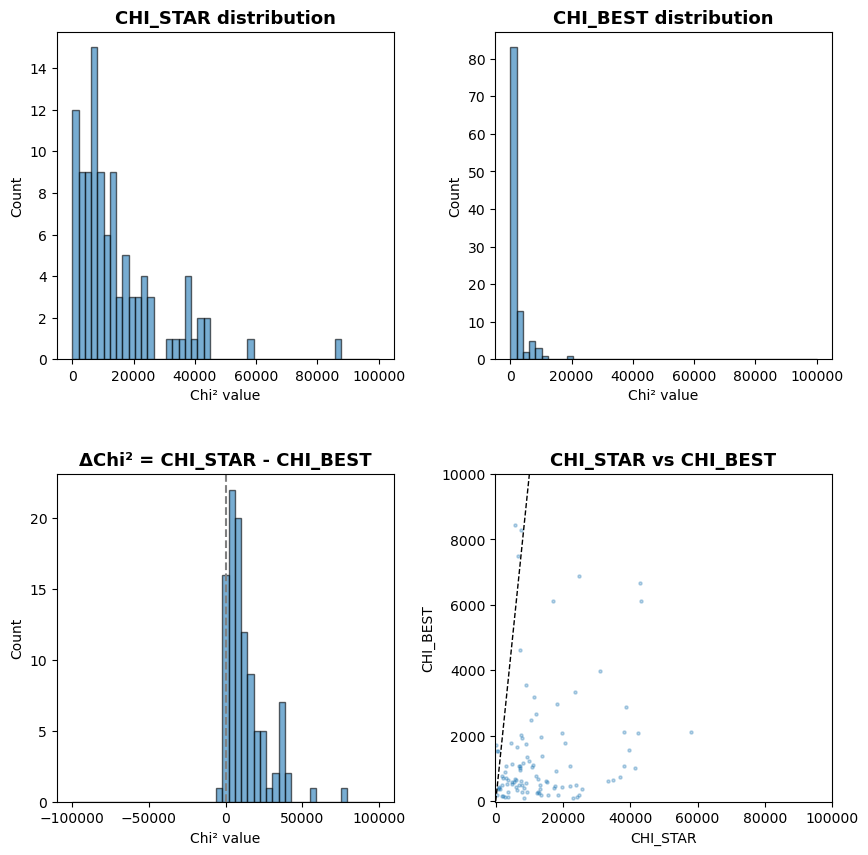

In [16]:
# %matplotlib widget
###stars 

lsp.chi_stats(data = photoz_dc2_gal[(photoz_dc2_gal['ERR_MAG_OBS0']<0.01)], mask_min=-100000, mask_max=100000, bins=50, scatter_xlim=(-200, 100000), scatter_ylim=(-20, 10000))

$\Delta\chi$ analysis

In [19]:
delta = photoz_dc1['CHI_STAR']-photoz_dc1['CHI_BEST']
delta = delta[photoz_dc1['ERR_MAG_OBS0']<=0.1]

In [ ]:
print("n(Delta>0) / n = ", len(delta[delta>0])/len(delta))

In [ ]:
lsp.more_chi_stats(data = photoz_dc1, mask_min=-100, mask_max=300, bins=100)

In [ ]:
plt.figure()
delta_chi=photoz_dc1['CHI_STAR'] - photoz_dc1['CHI_BEST']
hist_range = (-1000,1000)
plt.hist(delta_chi, bins=100, alpha=0.7, edgecolor='black', color='purple', range=hist_range)
plt.axvline(0, color='gray', linestyle='--')
plt.show()

flag VS stype

In [ ]:
###Flag and type distribution

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.hist(zphota["PDZ_FLAG"][zphota["PDZ_FLAG"]>=0], bins=100, alpha=0.7, edgecolor='black')#, density=True)#, log=True)
plt.title("PDZ flag distribution")
plt.subplot(122)
plt.title("S-type distribution")
plt.hist(zphota["S_TYPE"], bins=100, alpha=0.7, edgecolor='black', color='orange')#, density=True)#, log=True)

# plt.ylim(0,0.010)
plt.legend()
plt.show()

In [ ]:
import seaborn as sns
plt.rcParams.update({'font.size': 6})
contingency = pd.crosstab(zphota["S_TYPE"], zphota["PDZ_FLAG"])

# Plot avec seaborn
plt.figure(figsize=(18,16))
sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 6.5})
plt.title("Distribution des flags par type d'étoile")
plt.ylabel("Type d'étoile")
plt.xlabel("Flag")
plt.show()


In [ ]:
plt.figure(figsize=(15,13))

sns.stripplot(x=zphota["CHI_STAR"]-zphota["CHI_BEST"], y=zphota["S_TYPE"], jitter=True, size=6)
plt.title("DeltaChi distribution as a function of source-type")
plt.ylabel("Type d'étoile")
plt.xlabel("Delta Chi =  Chi_star - Chi_best")
plt.xlim(-1e4,1e4)
plt.show()

In [ ]:
###Flag and type distribution

plt.figure(figsize=(4, 4))
mask=(zphota["CHI_STAR"]<1e4) & (zphota["CHI_BEST"]<1e4)
plt.hist(zphota["CHI_STAR"] - zphota["CHI_BEST"], bins=1000000, alpha=0.7, edgecolor='black')#, density=True)#, log=True)
plt.title("Delta Chi dist")


# plt.ylim(0,0.010)
plt.legend()
plt.show()

In [ ]:
### Generate pandas df from output catalog ###
base_dir = os.path.abspath(os.path.join(os.getcwd(), '../..')) #change to your lephare base_dir
CAT_OUT = os.path.join(base_dir, 'training_stats/simulation_catalogs/star_gal/DESstars_Buzzard_PICKLES_DES_kk_typed.out')


photoz_des = lsp.lephare_to_pandas(CAT_OUT)
### Clean error values
photoz_des = photoz_des[photoz_des['Z_BEST'] != -99.9]
print(list(photoz_des.columns.values))
photoz_des